## K-means Clustering Analysis of Air Pollution Data


Air pollution is a huge environmental and health concern globally (Bakar et al., 2024). It’s sources include power generation, residential energy, agricultural and industrial waste (Borge et al., 2022) Air pollution has adverse effects on human health as well as the environment (Manimegalai et al., 2016). The world health organization states that roughly 2.4 billion people are exposed to quite high levels of air pollution and that 7 million annual deaths are associated with air pollution. The monitoring of air pollution is therefore crucial for environmental management and public health protection.
Machine learning algorithms play a crucial role here. Particularly cluster analysis, which helps identify regions with similar pollution characteristics thereby enabling policymakers to develop targeted strategies (Caron et al., 2019). The most commonly applied algorithm in air pollution studies is k-means (Omar et al., 2022). K-means clustering is an unsupervised algorithm that is centroid based and is used for partitioning a dataset into a pre-defined number of clusters (Analytics Vidhya, 2025). This report applies k-means clustering to the airpoll dataset to draw insights about the widely studied pollutants and possibly suggest intervention strategies.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

#loading the dataset
df = pd.read_csv("airpoll.csv")


Dataset Shape: (3347, 5)

First 5 rows:
     SO2    NO2     O3  PM2.5   PM10
0  12.07  26.21  50.27  30.13  49.60
1   9.96  26.41  50.73  39.43  63.53
2  13.04  28.18  59.66  30.05  51.60
3  14.11  30.43  45.04  35.74  59.89
4  16.47  25.97  46.35  22.80  39.99

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3347 entries, 0 to 3346
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SO2     3347 non-null   float64
 1   NO2     3347 non-null   float64
 2   O3      3347 non-null   float64
 3   PM2.5   3347 non-null   float64
 4   PM10    3347 non-null   float64
dtypes: float64(5)
memory usage: 130.9 KB
None

Basic Statistics:
               SO2          NO2           O3        PM2.5         PM10
count  3347.000000  3347.000000  3347.000000  3347.000000  3347.000000
mean     15.457774    30.233872    49.046191    30.840385    53.069074
std       7.958897     9.840317    13.678753    10.881879    19.495487
min     

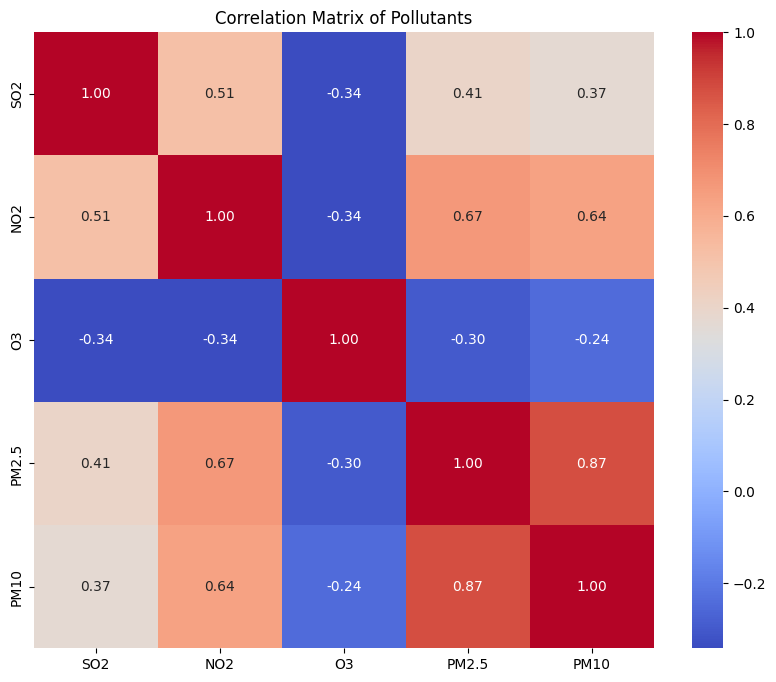

In [11]:
#Basic statistics
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

# Calculation of the correlation matrix
correlation_matrix = df.corr()

# Plot the correlation matrix using seaborn heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Pollutants')
plt.savefig('correlation_matrix.png')
plt.show()

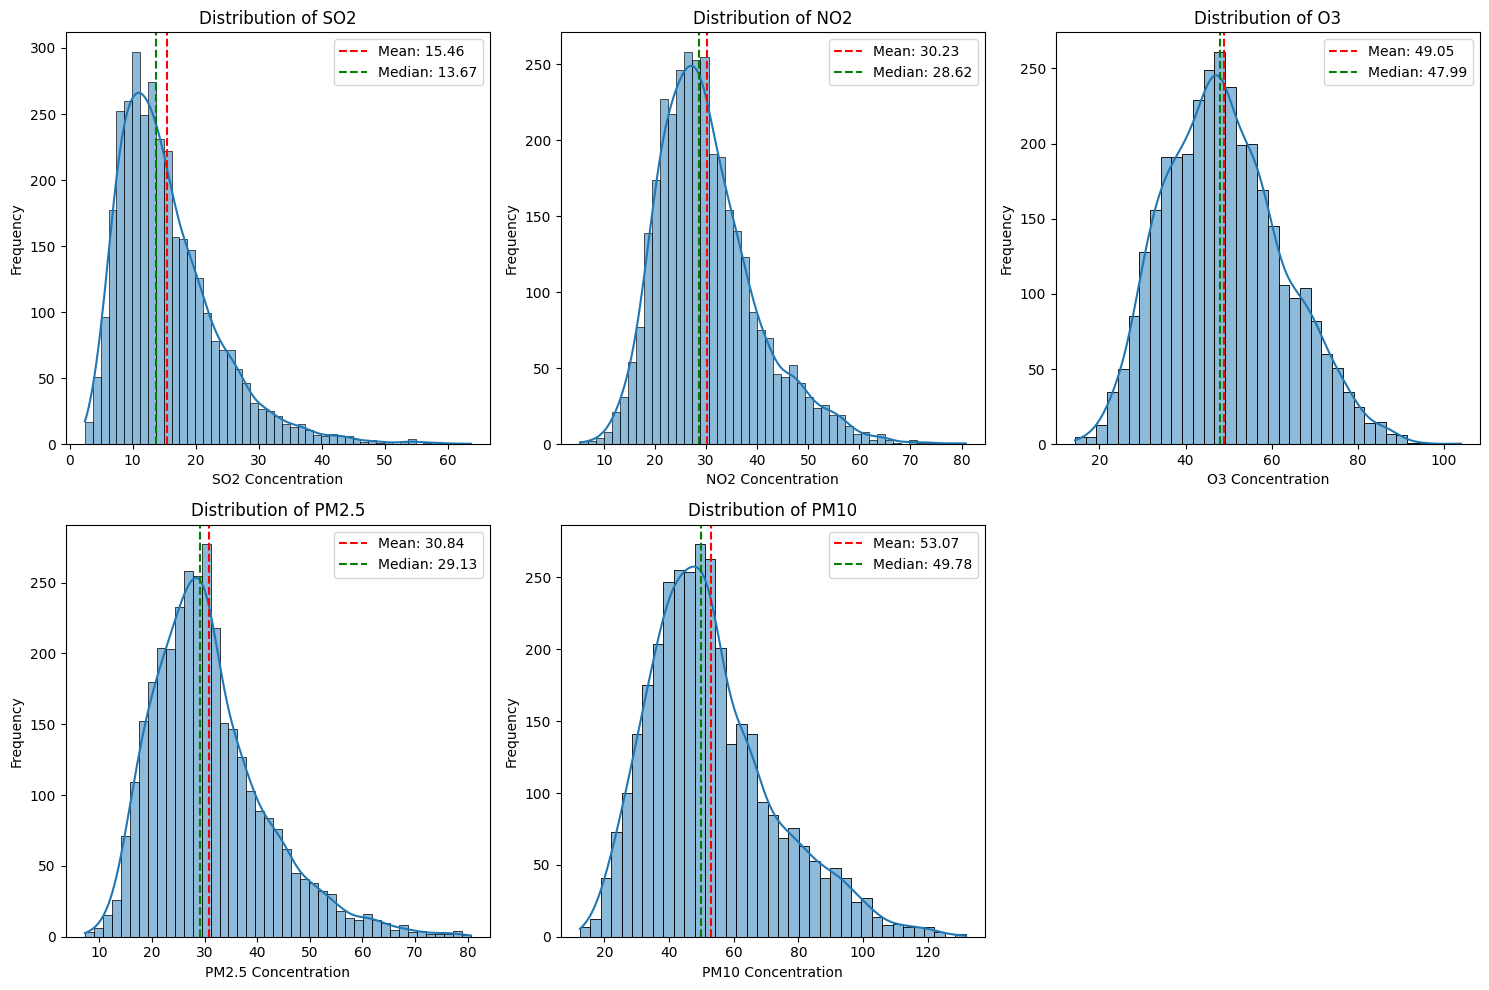

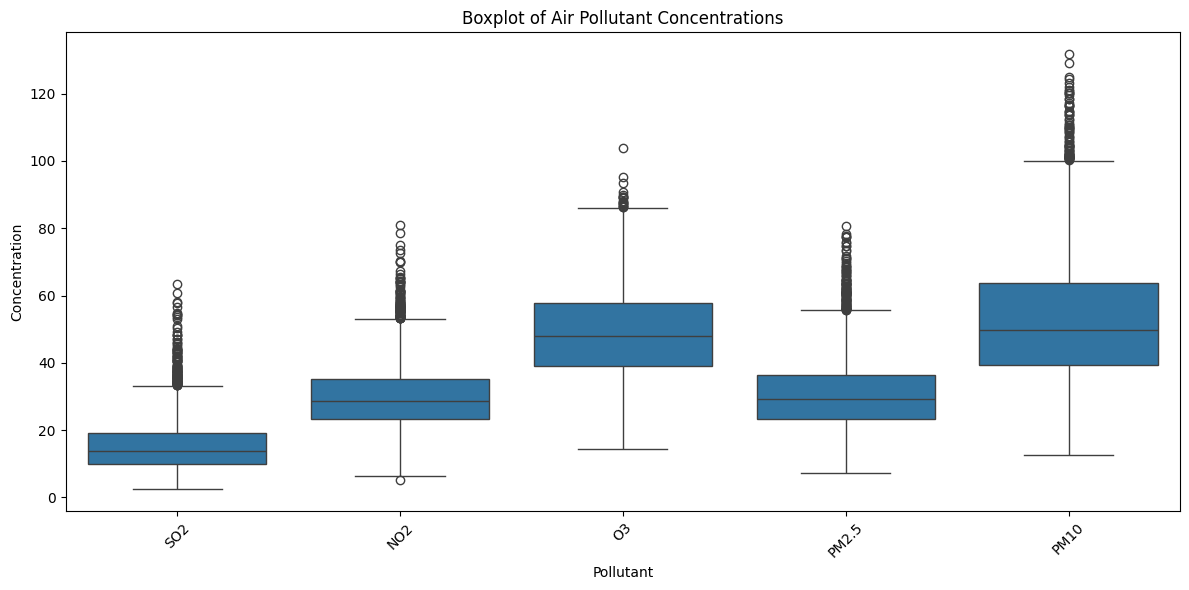

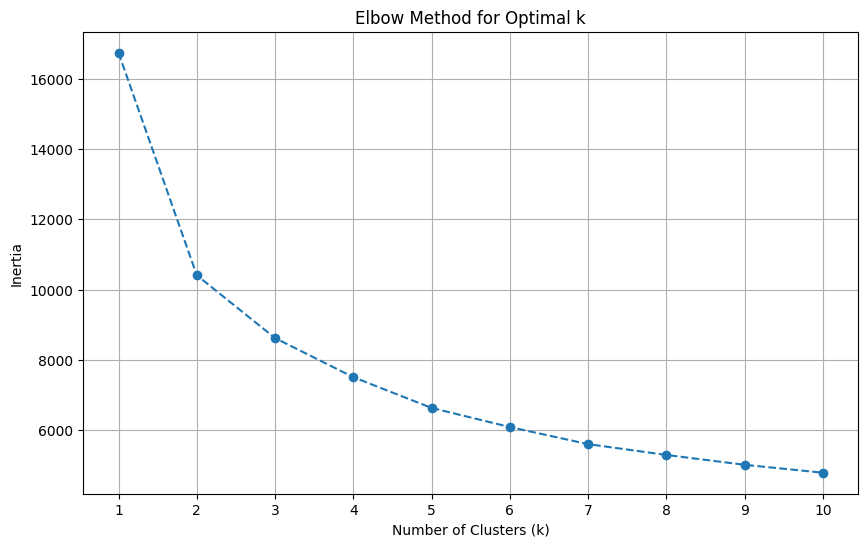

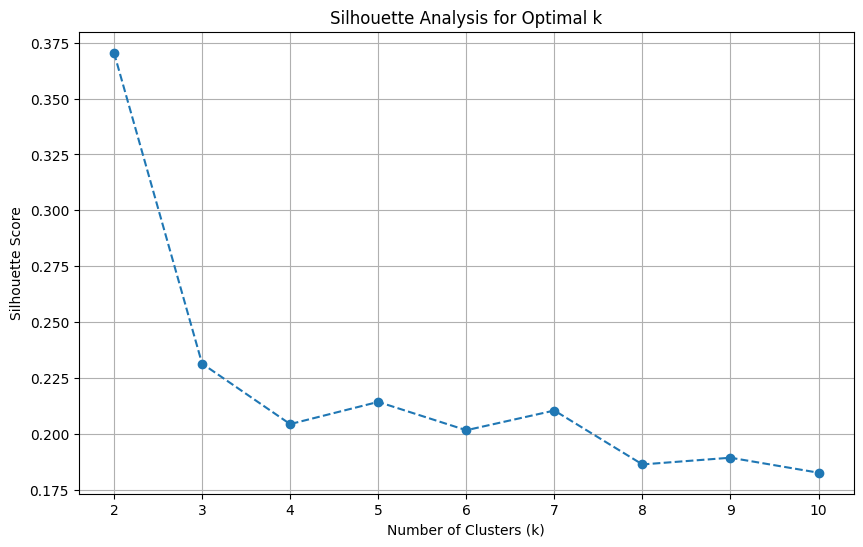

Cluster Sizes:
Cluster
0     531
1    1312
2    1504
Name: count, dtype: int64

Cluster Means:
               SO2        NO2         O3      PM2.5       PM10
Cluster                                                       
0        23.649755  45.757100  39.388512  48.587495  83.963559
1        10.665648  23.388796  57.885343  22.971913  39.152264
2        16.745891  30.724501  44.745166  31.438604  54.301709


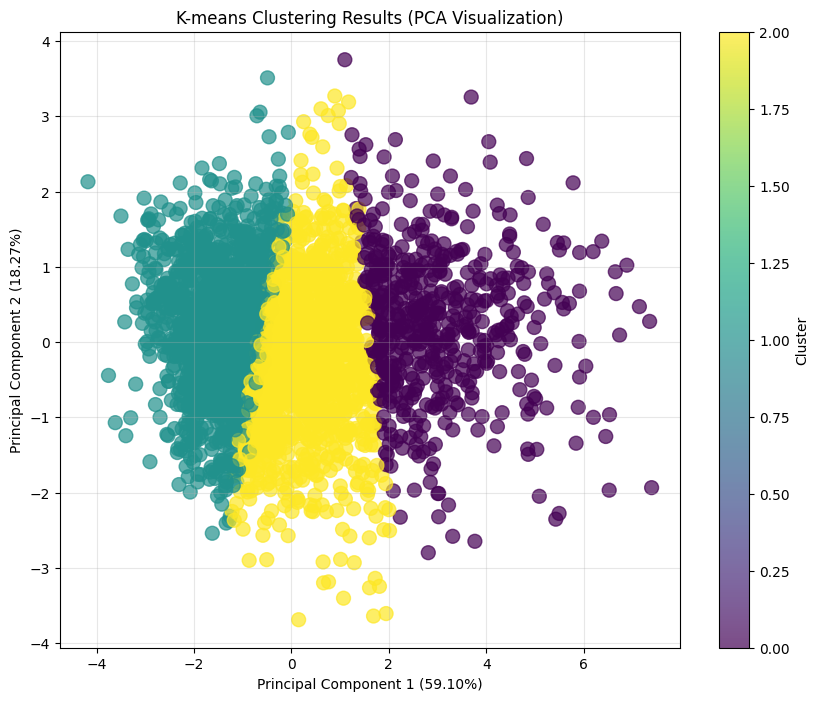

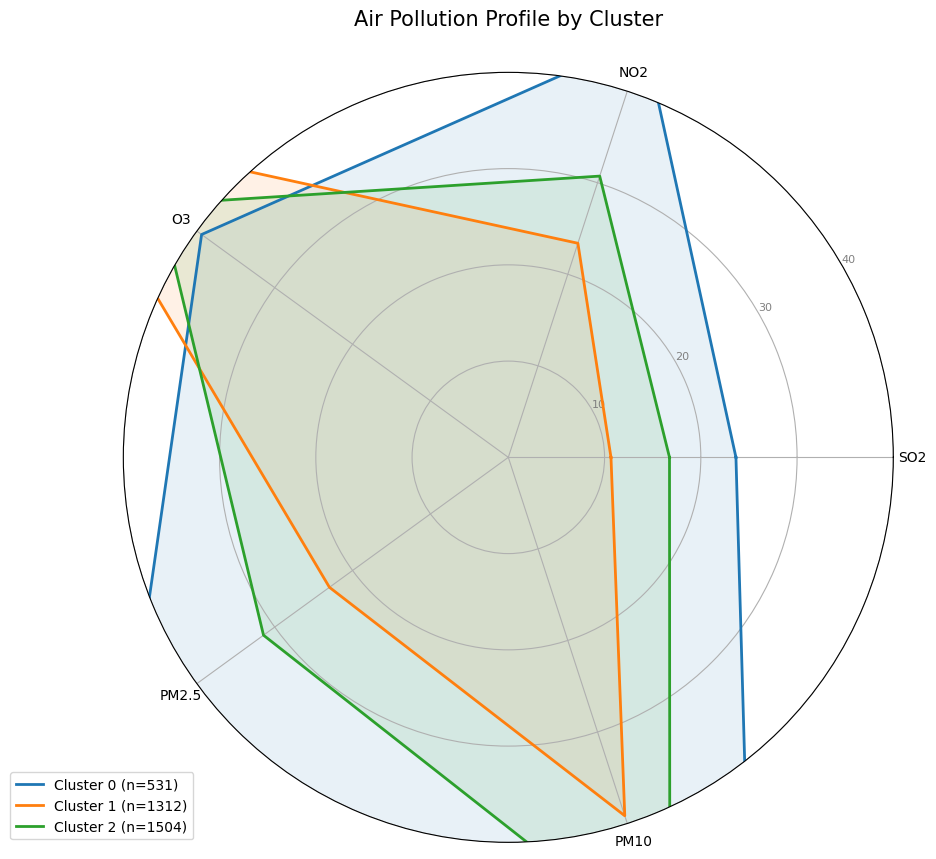

In [12]:

#Setting up the visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()
pollutants = df.columns

for i, pollutant in enumerate(pollutants):

    sns.histplot(df[pollutant], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {pollutant}')
    axes[i].set_xlabel(f'{pollutant} Concentration')
    axes[i].set_ylabel('Frequency')


    axes[i].axvline(df[pollutant].mean(), color='red', linestyle='--',
                    label=f'Mean: {df[pollutant].mean():.2f}')
    axes[i].axvline(df[pollutant].median(), color='green', linestyle='--',
                    label=f'Median: {df[pollutant].median():.2f}')
    axes[i].legend()


if len(pollutants) < 6:
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.savefig('pollutant_distributions.png', dpi=300)
plt.show()

#Boxplot for all pollutants
plt.figure(figsize=(12, 6))
df_melted = df.melt(var_name='Pollutant', value_name='Concentration')
sns.boxplot(x='Pollutant', y='Concentration', data=df_melted)
plt.title('Boxplot of Air Pollutant Concentrations')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('pollutant_boxplots.png', dpi=300)
plt.show()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

#Elbow method
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

#elbow curve plot
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_range)
plt.grid(True)
plt.savefig('elbow_method.png', dpi=300)
plt.show()

from sklearn.metrics import silhouette_score

silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(scaled_data)
    silhouette_avg = silhouette_score(scaled_data, cluster_labels)
    silhouette_scores.append(silhouette_avg)

#Plot silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis for Optimal k')
plt.xticks(k_range)
plt.grid(True)
plt.savefig('silhouette_analysis.png', dpi=300)
plt.show()

#k-means clustering with k=3
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)

#Add cluster labels to original data
df['Cluster'] = clusters

#Analyze cluster characteristics
cluster_summary = df.groupby('Cluster').mean()
cluster_sizes = df['Cluster'].value_counts().sort_index()

print("Cluster Sizes:")
print(cluster_sizes)
print("\nCluster Means:")
print(cluster_summary)

#PCA for dimensionality reduction for visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_data)
pca_df = pd.DataFrame(data=principal_components,
                     columns=['PC1', 'PC2'])
pca_df['Cluster'] = clusters

#Visualize clusters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'],
                     c=pca_df['Cluster'], cmap='viridis',
                     s=100, alpha=0.7)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.title('K-means Clustering Results (PCA Visualization)')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.savefig('cluster_visualization.png', dpi=300)
plt.show()

#Radar chart for cluster profiles
from math import pi

#Calculate mean values for each cluster
categories = list(df.columns[:-1])
N = len(categories)

#Radar chart
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, polar=True)

#Compute angle for each category
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Complete the circle

for cluster in range(optimal_k):
    values = cluster_summary.loc[cluster].values.flatten().tolist()
    values += values[:1]  # Complete the circle
    ax.plot(angles, values, linewidth=2,
            label=f'Cluster {cluster} (n={cluster_sizes[cluster]})')
    ax.fill(angles, values, alpha=0.1)

#Add labels
plt.xticks(angles[:-1], categories)
ax.set_rlabel_position(30)
plt.yticks([10, 20, 30, 40], ["10", "20", "30", "40"], color="grey", size=8)
plt.ylim(0, 40)
plt.title('Air Pollution Profile by Cluster', size=15, y=1.05)
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.savefig('cluster_profiles_radar.png', dpi=300, bbox_inches='tight')
plt.show()

Descriptive statistics (table 2) show that O3 and PM10 are the dominant pollutants with higher averages than SO2, NO2, and PM2.5. These two pollutants also exhibit larger variability as seen with their std values, meaning there’s more fluctuations in their concentrations. While average values are moderate, the high maximum values for all pollutants point to occasional spikes and this signals poor air quality. The outliers revealed by the boxplots (fig.5) further supports this observation
In figure 1 the strong correlations between most pollutants suggest they often originate from common sources, for instance: industrial activities and vehicle emissions. The weaker correlations between O3 and other pollutants indicates that it may have different formation mechanisms or sources. This is further seen in figure 5 in cluster 1 where other pollutants are low and Ozone is highest.
Optimal K was determined to be 3 using both the elbow and silhouette analysis. This provided distinct and well-separated clusters. Our K-means clustering (fig.5) shows that the clusters are fairly well separated, with some minor overlap at the boundaries. This is indication that while the algorithm may not have fully disentangled complex relationships in the data, it still captured meaningful patterns in air quality. Figure 6 further confirms the trade-off between other gases and ozone as already seen in the correlation matrix, thereby suggesting that while cluster 1 has cleaner air, it is ozone-prone. It is evident that O3 and PM10 are the dominating pollutants. Since particulate matter is linked to respiratory and cardiovascular risks (Ariff et al., 2023), interventions are needed to reduce air pollution.
